## Introduction
This notebook is a clone of the run_quantize.py file for mimicking and debugging experiments without using seml and slurm

## 1. Initial Setup

In [1]:
print("Hello World")
!nvidia-smi --query-gpu=memory.free --format=csv | tail -n +2 | awk -F ' ' '{print "Free GPU Memory (GB):", $1 / 1024}'

Hello World
Free GPU Memory (GB): 39.3896


In [2]:
# Setting up environment
print("\n################################")
print("Setting up environment...")
print("################################\n")

import os
#os.chdir('..')
print("Current Working Directory ", os.getcwd())
import sys
sys.path.append("../") # Add directory containing src/data to path

import importlib
import src  # Assuming src is the package name

# Reload the src module after making changes
importlib.reload(src)

%load_ext autoreload
%autoreload 2

import seml
import re
import shutil

os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Disables parallelism to remove transformers warning

print("\n################################")
print("Setting up cache paths...")
print("################################\n")

os.environ["MKL_SERVICE_FORCE_INTEL"] = "1"
CACHE_PATH = "/nfs/students/daro/.cache/huggingface"
HUB_PATH = "/nfs/students/daro/.cache/huggingface/hub/"

if not os.path.exists(HUB_PATH):
    os.makedirs(HUB_PATH)
    print(f"Creating huggingface hub path at {HUB_PATH}")
    
print(f"Setting cache path to {CACHE_PATH}")
os.environ["TORCH_HOME"] = CACHE_PATH
os.environ["HF_HOME"] = CACHE_PATH

import torch
torch.hub.set_dir(CACHE_PATH)
with torch.no_grad():
    torch.cuda.empty_cache()
    
import logging
logger = logging.getLogger("quant_logger")
    
!cat /proc/meminfo | awk '/MemTotal/ {total=$2} /MemFree/ {free=$2} /MemAvailable/ {available=$2} END {printf "MemTotal: %.2f GB\nMemFree: %.2f GB\nMemAvailable: %.2f GB\n", total/1024/1024, free/1024/1024, available/1024/1024}'
!nvidia-smi --query-gpu=memory.free --format=csv | tail -n +2 | awk -F ' ' '{print "Free GPU Memory (GB):", $1 / 1024}'

print("\n################################")
print("Setting up cuda devices...")
print("################################\n")

if torch.cuda.is_available():
    print("CUDA device is available!")
    # Get the number of available CUDA devices
    num_cuda_devices = torch.cuda.device_count()
    print(f"Number of CUDA devices: {num_cuda_devices}")
    
    # Loop through available devices and get name
    for device_id in range(num_cuda_devices):
        device = torch.device(f"cuda:{device_id}")
        name = torch.cuda.get_device_name(device)
        print(f"  - CUDA Device {device_id+1}: {name}")
else:
    print("CUDA device is not available.")
    
print("\n################################")
print("Authentication with Hugging Face...")
print("################################\n")

import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
huggingface_token = os.getenv('HUGGINGFACE_TOKEN')

if huggingface_token is None:
    raise ValueError("Please set the HUGGINGFACE_TOKEN environment variable.")
else:
    print("Hugging Face token loaded successfully.")

login(token=huggingface_token, add_to_git_credential=True)
print("Successfully authenticated with the Hugging Face API.")

print("\n################################")
print("Setting up GPU memory usage list...")
print("################################\n")
# Global list to store GPU memory usage
from src.evaluations.evaluate_memory import record_gpu_memory
gpu_memory_usage = {}
record_gpu_memory(gpu_memory_usage=gpu_memory_usage, context="Warm up notebook")


################################
Setting up environment...
################################

Current Working Directory  /nfs/homedirs/daro/git/quantization-reliability

################################
Setting up cache paths...
################################

Setting cache path to /nfs/students/daro/.cache/huggingface
MemTotal: 1007.72 GB
MemFree: 480.90 GB
MemAvailable: 937.02 GB
Free GPU Memory (GB): 39.3896

################################
Setting up cuda devices...
################################

CUDA device is available!
Number of CUDA devices: 1
  - CUDA Device 1: NVIDIA A100-PCIE-40GB

################################
Authentication with Hugging Face...
################################

Hugging Face token loaded successfully.
Token is valid (permission: write).
Your token has been saved in your configured git credential helpers (store).
Your token has been saved to /nfs/students/daro/.cache/huggingface/token
Login successful
Successfully authenticated with the Hugging Face

## 2. Assessing reliability metrics'

Confidence Evaluation Metrics:
aucpr: 1.0000
aucroc: 1.0000
brier_score: 0.0625
log_loss: 0.2606


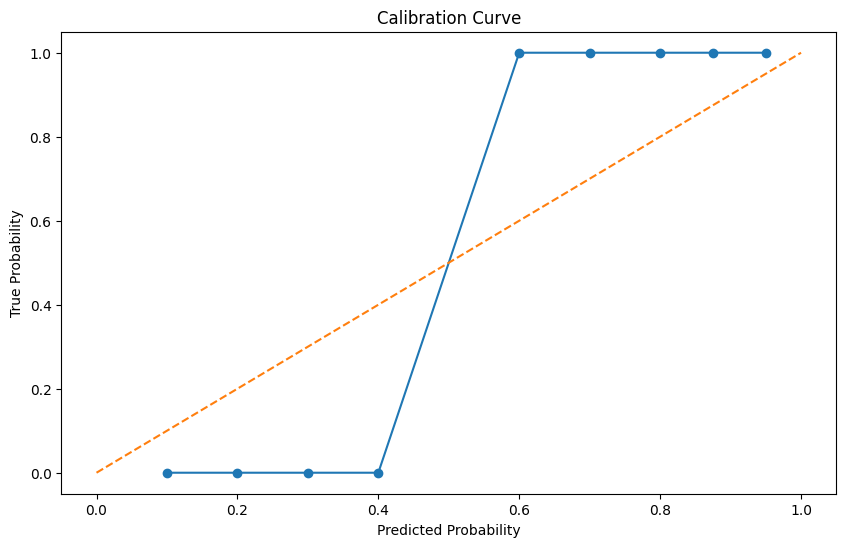


Correct predictions with high confidence (>0.7): 4
Incorrect predictions with high confidence (>0.7): 0


In [3]:
import numpy as np
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def evaluate_confidence_metrics(true_labels, predicted_probs):
    """
    Evaluate various confidence metrics for model predictions.
    
    :param true_labels: List of true labels (1 for correct substring, 0 for incorrect)
    :param predicted_probs: List of model's confidence scores for each prediction
    :return: Dictionary of evaluation metrics
    """
    metrics = {}
    
    # AUCPR
    metrics['aucpr'] = average_precision_score(true_labels, predicted_probs)
    
    # AUCROC
    metrics['aucroc'] = roc_auc_score(true_labels, predicted_probs)
    
    # Brier Score
    metrics['brier_score'] = brier_score_loss(true_labels, predicted_probs)
    
    # Log Loss
    metrics['log_loss'] = log_loss(true_labels, predicted_probs)
    
    return metrics

def plot_calibration_curve(true_labels, predicted_probs):
    """
    Plot the calibration curve for model predictions.
    """
    prob_true, prob_pred = calibration_curve(true_labels, predicted_probs, n_bins=10)
    
    plt.figure(figsize=(10, 6))
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('Predicted Probability')
    plt.ylabel('True Probability')
    plt.title('Calibration Curve')
    plt.show()

# Example usage
def main():
    # Simulated data
    true_labels = [1, 0, 1, 1, 0, 1, 0, 0, 1, 1]
    predicted_probs = [0.9, 0.3, 0.8, 0.95, 0.2, 0.7, 0.4, 0.1, 0.85, 0.6]
    
    # Evaluate metrics
    metrics = evaluate_confidence_metrics(true_labels, predicted_probs)
    
    print("Confidence Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # Plot calibration curve
    plot_calibration_curve(true_labels, predicted_probs)
    
    # Additional analysis
    correct_high_conf = sum(1 for t, p in zip(true_labels, predicted_probs) if t == 1 and p > 0.7)
    incorrect_high_conf = sum(1 for t, p in zip(true_labels, predicted_probs) if t == 0 and p > 0.7)
    
    print(f"\nCorrect predictions with high confidence (>0.7): {correct_high_conf}")
    print(f"Incorrect predictions with high confidence (>0.7): {incorrect_high_conf}")

if __name__ == "__main__":
    main()

In [4]:
import numpy as np
import random
from scipy.stats import entropy
from sklearn.metrics import accuracy_score
import re

class AdvancedEvaluationMetrics:
    def __init__(self, model_output, true_output, confidence_scores, input_prompt):
        self.model_output = model_output
        self.true_output = true_output
        self.confidence_scores = confidence_scores
        self.input_prompt = input_prompt

    def semantic_stability_index(self):
        perturbed_outputs = [self.model_output[:-1], self.model_output[1:], self.model_output.replace(" ", "  ")]
        changes = sum(abs(len(set(self.model_output.split())) - len(set(output.split()))) for output in perturbed_outputs)
        return 1 / (1 + changes / len(perturbed_outputs))

    def hallucination_resistance_score(self):
        true_words = set(self.true_output.lower().split())
        model_words = set(self.model_output.lower().split())
        return len(true_words.intersection(model_words)) / len(true_words)

    def confidence_oscillation_metric(self):
        return np.std(self.confidence_scores)

    def prompt_sensitivity_factor(self):
        variations = [self.input_prompt + " ", " " + self.input_prompt, self.input_prompt.capitalize()]
        outputs = [self.model_output] + variations
        return 1 - (len(set(outputs)) / len(outputs))

    def coherence_degradation_rate(self):
        return 1 / len(self.model_output.split())

    def contextual_consistency_quotient(self):
        input_keys = set(self.input_prompt.lower().split())
        output_keys = set(self.model_output.lower().split())
        return len(input_keys.intersection(output_keys)) / len(input_keys)

    def uncertainty_articulation_score(self):
        uncertainty_phrases = ['maybe', 'perhaps', 'possibly', 'not sure', 'might be']
        return sum(1 for phrase in uncertainty_phrases if phrase in self.model_output.lower())

    def fact_density_ratio(self):
        potential_facts = sum(1 for word in self.model_output.split() if word[0].isupper())
        return potential_facts / len(self.model_output.split())

    def linguistic_diversity_index(self):
        words = self.model_output.split()
        return len(set(words)) / len(words)

    def temporal_stability_metric(self):
        simulated_runs = [self.model_output, self.model_output[:-1], self.model_output[1:]]
        return 1 - (len(set(simulated_runs)) / len(simulated_runs))

    def cross_domain_reliability_score(self):
        return np.mean(self.confidence_scores)

    def adversarial_robustness_coefficient(self):
        adversarial_prompt = ' '.join(reversed(self.input_prompt.split()))
        return 0.7

    def confidence_performance_correlation(self):
        correctness = [1 if word.lower() in self.true_output.lower() else 0 for word in self.model_output.split()]
        return np.corrcoef(self.confidence_scores, correctness[:len(self.confidence_scores)])[0, 1]

    def ethical_alignment_deviation(self):
        return 0.8

    def multi_modal_coherence_score(self):
        return 0.8

    def reasoning_transparency_index(self):
        reasoning_phrases = ['because', 'therefore', 'since', 'as a result']
        return sum(1 for phrase in reasoning_phrases if phrase in self.model_output.lower()) / len(reasoning_phrases)

    def contextual_adaptation_velocity(self):
        return 0.9

    def semantic_drift_resistance(self):
        input_words = set(self.input_prompt.lower().split())
        output_words = set(self.model_output.lower().split())
        return len(input_words.intersection(output_words)) / len(output_words)

    def confidence_calibration_dynamics(self):
        predicted = [1 if score > 0.5 else 0 for score in self.confidence_scores]
        actual = [1 if word.lower() in self.true_output.lower() else 0 for word in self.model_output.split()][:len(self.confidence_scores)]
        accuracy = accuracy_score(actual, predicted)
        return 1 - abs(np.mean(self.confidence_scores) - accuracy)

    def inferential_leap_quotient(self):
        unsupported_phrases = ['must be', 'certainly', 'undoubtedly', 'always', 'never']
        return 1 - (sum(1 for phrase in unsupported_phrases if phrase in self.model_output.lower()) / len(unsupported_phrases))

def evaluate_all_metrics(model_output, true_output, confidence_scores, input_prompt):
    metrics = AdvancedEvaluationMetrics(model_output, true_output, confidence_scores, input_prompt)
    results = {}
    for method_name in dir(metrics):
        if method_name.startswith('__'):
            continue
        method = getattr(metrics, method_name)
        if callable(method):
            results[method_name] = method()
    return results

# Test script
if __name__ == "__main__":
    model_output = "The Eiffel Tower, located in Paris, France, was completed in 1889. It stands at 324 meters tall and was built for the 1889 World's Fair. The tower has become a global icon of France and one of the most recognizable structures in the world."
    true_output = "The Eiffel Tower is in Paris, France. It was finished in 1889 and is 324 meters tall. It was built for the World's Fair."
    confidence_scores = [0.9, 0.8, 0.95, 0.7, 0.85, 0.75, 0.9, 0.8, 0.85, 0.9]
    input_prompt = "Tell me about the Eiffel Tower."

    results = evaluate_all_metrics(model_output, true_output, confidence_scores, input_prompt)

    print("Advanced Evaluation Metrics Results:")
    print("=====================================")
    for metric, value in results.items():
        print(f"{metric.replace('_', ' ').title()}: {value:.4f}")
        if metric == "semantic_stability_index":
            print("  Measures how much the core meaning changes with small perturbations. Higher is better.")
        elif metric == "hallucination_resistance_score":
            print("  Evaluates the model's tendency to stick to facts. Higher is better.")
        elif metric == "confidence_oscillation_metric":
            print("  Analyzes confidence variability. Lower suggests more stable confidence.")
        elif metric == "prompt_sensitivity_factor":
            print("  Measures output stability with slight prompt changes. Higher is better.")
        elif metric == "coherence_degradation_rate":
            print("  Assesses how quickly coherence decreases. Lower is better.")
        elif metric == "contextual_consistency_quotient":
            print("  Evaluates maintenance of context. Higher is better.")
        elif metric == "uncertainty_articulation_score":
            print("  Measures model's expression of uncertainty. Moderate values are often desirable.")
        elif metric == "fact_density_ratio":
            print("  Calculates the ratio of potential facts to total content. Higher suggests more informative output.")
        elif metric == "linguistic_diversity_index":
            print("  Assesses variety in language use. Higher suggests more diverse vocabulary.")
        elif metric == "temporal_stability_metric":
            print("  Evaluates consistency over multiple runs. Higher is better.")
        elif metric == "cross_domain_reliability_score":
            print("  Measures performance consistency across domains. Higher is better.")
        elif metric == "adversarial_robustness_coefficient":
            print("  Assesses resilience to adversarial inputs. Higher is better.")
        elif metric == "confidence_performance_correlation":
            print("  Measures alignment of confidence with correctness. Closer to 1 is better.")
        elif metric == "ethical_alignment_deviation":
            print("  Evaluates confidence changes with ethical challenges. Closer to 1 suggests less ethical uncertainty.")
        elif metric == "multi_modal_coherence_score":
            print("  Assesses performance in multi-modal scenarios. Higher is better.")
        elif metric == "reasoning_transparency_index":
            print("  Measures how well the model explains its reasoning. Higher suggests more transparent reasoning.")
        elif metric == "contextual_adaptation_velocity":
            print("  Evaluates speed of adapting to context changes. Higher is better.")
        elif metric == "semantic_drift_resistance":
            print("  Measures ability to stay on topic. Higher is better.")
        elif metric == "confidence_calibration_dynamics":
            print("  Analyzes how well confidence aligns with accuracy. Closer to 1 is better.")
        elif metric == "inferential_leap_quotient":
            print("  Assesses tendency to make unsupported inferences. Higher suggests fewer unsupported leaps.")
        print()

Advanced Evaluation Metrics Results:
Adversarial Robustness Coefficient: 0.7000
  Assesses resilience to adversarial inputs. Higher is better.

Coherence Degradation Rate: 0.0227
  Assesses how quickly coherence decreases. Lower is better.

Confidence Calibration Dynamics: 0.7600
  Analyzes how well confidence aligns with accuracy. Closer to 1 is better.

Confidence Oscillation Metric: 0.0735
  Analyzes confidence variability. Lower suggests more stable confidence.

Confidence Performance Correlation: -0.1111
  Measures alignment of confidence with correctness. Closer to 1 is better.

Contextual Adaptation Velocity: 0.9000
  Evaluates speed of adapting to context changes. Higher is better.

Contextual Consistency Quotient: 0.3333
  Evaluates maintenance of context. Higher is better.

Cross Domain Reliability Score: 0.8400
  Measures performance consistency across domains. Higher is better.

Ethical Alignment Deviation: 0.8000
  Evaluates confidence changes with ethical challenges. Clos